In [197]:
import numpy as np
import fwdpy11
from sbi.utils import BoxUniform
import torch

class Recorder(object):
    def __init__(self, start):
        self.generation = []
        self.gbar = []
        self.wbar = []
        self.start = start    
        
    def __call__(self, pop, sampler):
        if pop.generation > self.start and (pop.generation % 10) == 0:
            self.generation.append(pop.generation)
            md=np.array(pop.diploid_metadata, copy=False)
            self.gbar.append(md['g'].mean())


def simulator(theta, seed=42, G=200, N=5000):
    s, mu, rho = 10**theta
    pop = fwdpy11.DiploidPopulation(N, 1.0)

    rng = fwdpy11.GSLrng(seed)

    gssmo = fwdpy11.GaussianStabilizingSelection.single_trait(
        [
            fwdpy11.Optimum(when=0, optimum=0.0, VS=1.0),
            fwdpy11.Optimum(when=0, optimum=2.0, VS=1.0),
        ]
    )

    p = {
        "nregions": [],
        "gvalue": fwdpy11.Additive(2.0, gssmo),
        "sregions": [fwdpy11.ExpS(0, 1, 1, s)],
        "recregions": [fwdpy11.PoissonInterval(0, 1., rho / float(4 * pop.N))],
        "rates": (mu, mu, None),
        # Keep mutations at frequency 1 in the pop if they affect fitness.
        "prune_selected": False,
        "demography": fwdpy11.ForwardDemesGraph.tubes([pop.N], burnin=G, burnin_is_exact=True),
        "simlen": G,
    }
    params = fwdpy11.ModelParams(**p)

    r = Recorder(start=0)
    fwdpy11.evolvets(rng, pop, params, G, recorder=r, suppress_table_indexing=True)
    return np.array(r.gbar)

prior = BoxUniform(low=torch.tensor([-2, -6, 1]), high=torch.tensor([-0.5, -3, 4]))


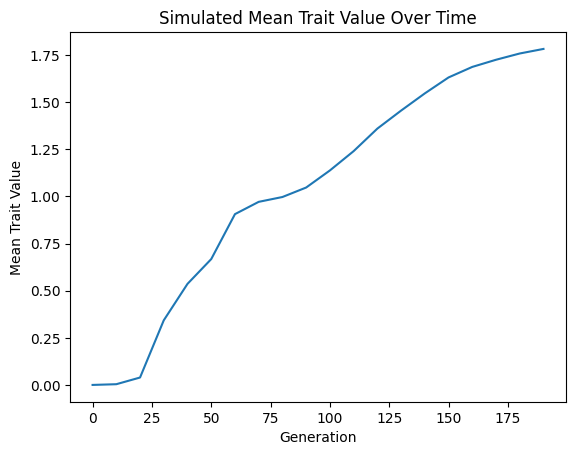

In [198]:
import matplotlib.pyplot as plt
theta = prior.sample((1,)).squeeze().numpy()
x = simulator(theta, seed=1)
plt.plot(10*np.arange(0,len(x)), x)
plt.xlabel("Generation")
plt.ylabel("Mean Trait Value")
plt.title("Simulated Mean Trait Value Over Time")
plt.show()


In [213]:
# sbi imports
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import sys
sys.path.append("../")
# from simulators import wrapper, GORDO

# def sim_iid(theta):
#     return wrapper(GORDO, reps=10, parameters=theta)


# Sample 10,000 parameter sets
num_samples = 30_000

# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)

# Check simulator, returns PyTorch simulator able to simulate batches.
sbi_simulator = process_simulator(simulator, prior, prior_returns_numpy)


# Generate training data
theta, x = simulate_for_sbi(sbi_simulator, proposal=prior, num_simulations=num_samples, num_workers=80)
print(x.shape, theta.shape)
torch.save(theta, "train_theta.pt")
torch.save(x, "train_x.pt")

  0%|          | 0/30000 [00:00<?, ?it/s]

torch.Size([30000, 20]) torch.Size([30000, 3])


In [ ]:
# Load saved data
train_theta = torch.load("train_theta.pt")
train_x = torch.load("train_x.pt").squeeze(1)  # shape: (num_samples, reps, features) or (num_samples, features) if reps squeezed


# Train NPE
inference = NPE(prior=prior)
density_estimator = inference.append_simulations(train_theta, train_x).train()
posterior = inference.build_posterior(density_estimator)

# Save the posterior model
import pickle
with open("posterior_singles.pkl", "wb") as f:
    pickle.dump(posterior, f)

 Training neural network. Epochs trained: 71

In [201]:
# load the posterior model
import pickle
with open("posterior_singles.pkl", "rb") as f:
    posterior = pickle.load(f)

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

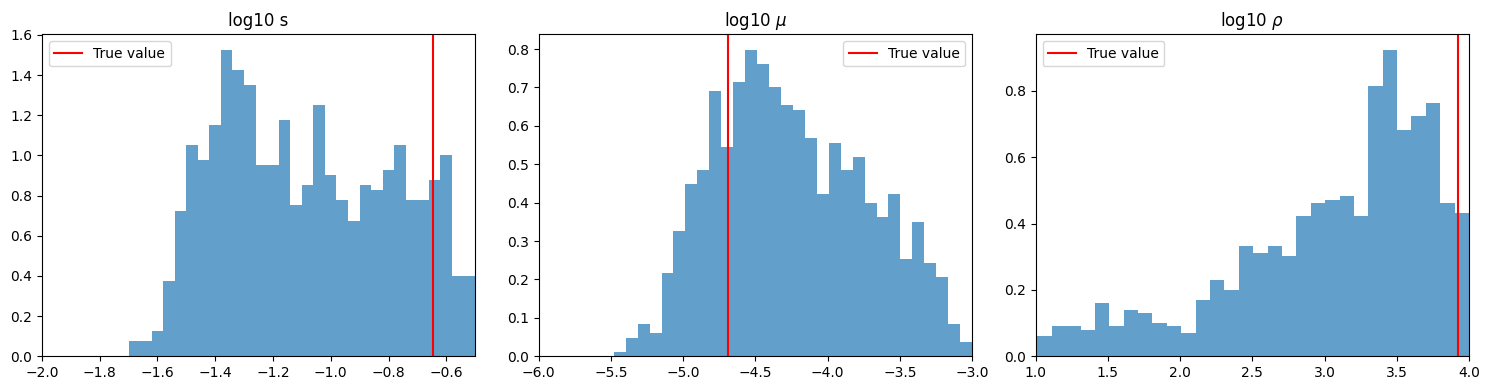

In [211]:
train_theta = torch.load("train_theta.pt")
theta = prior.sample((1,)).squeeze() # Example parameters in log10 space
samples = posterior.set_default_x(simulator(theta)).sample((1000,))
param_names = ["log10 s", "log10 $\mu$", "log10 $\\rho$"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.hist(samples[:, i].numpy(), bins=30, density=True, alpha=0.7)
    ax.axvline(theta[i], color='red', label='True value')
    ax.set_title(param_names[i])
    ax.set_xlim(prior.base_dist.low[i].item(), prior.base_dist.high[i].item())
    ax.legend()
plt.tight_layout()
plt.show()

Rejection Sampling: 1023it [00:09, 111.00it/s]                         


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

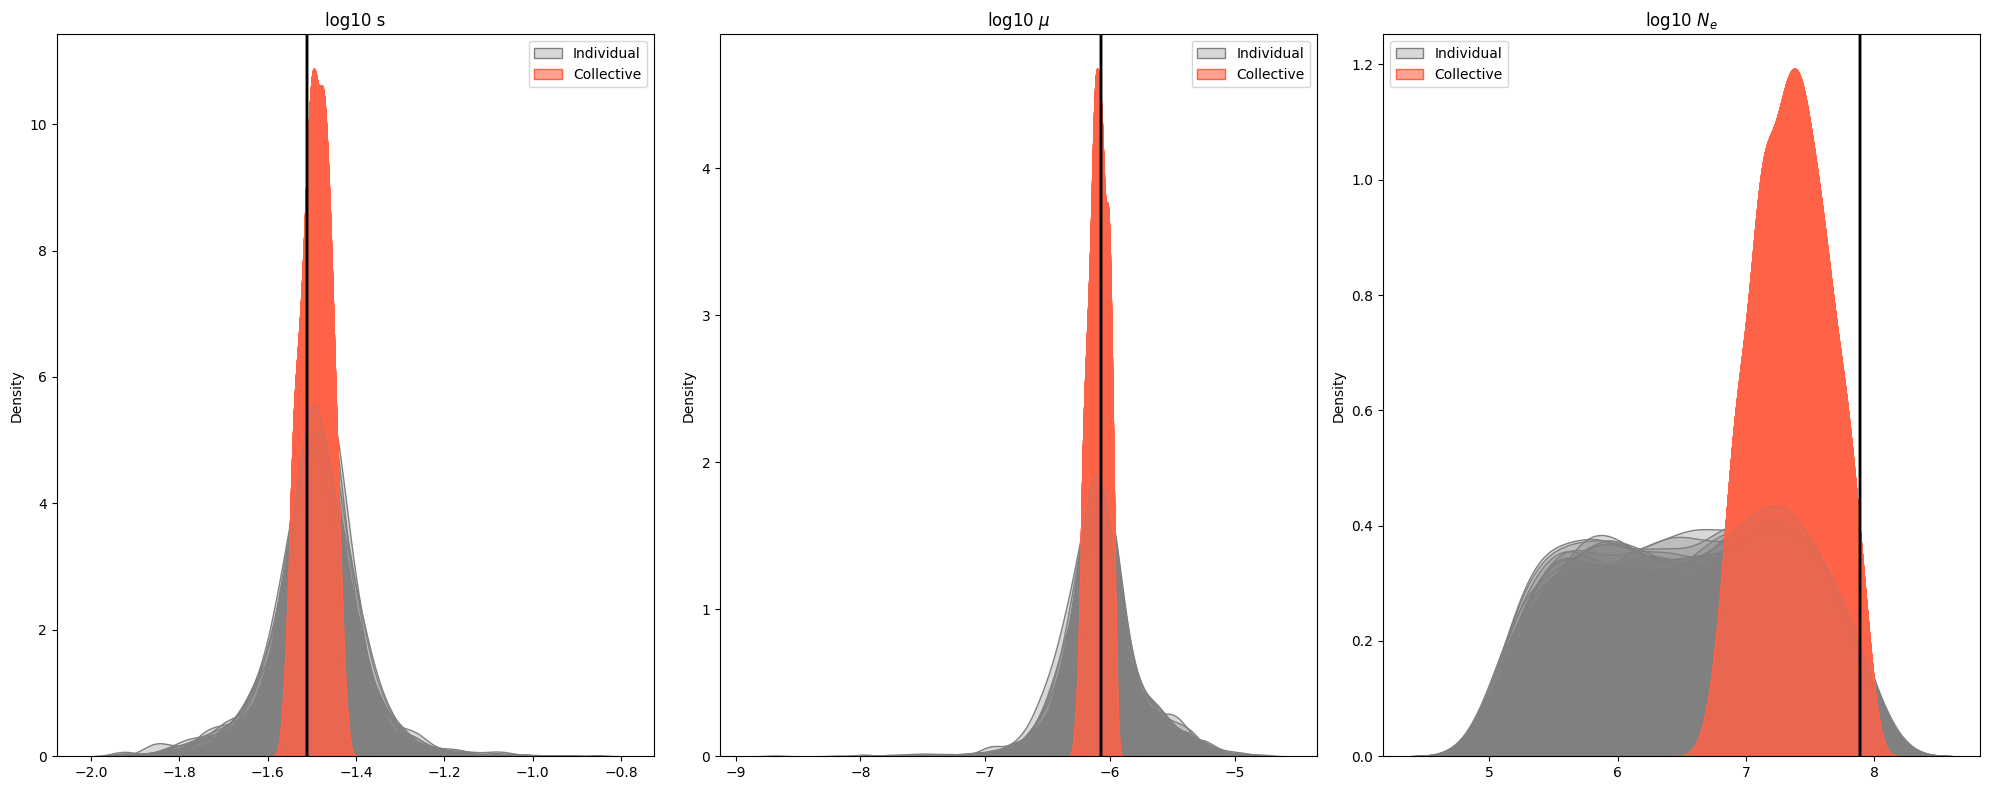

In [56]:
import sys
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from seaborn import kdeplot

x = torch.cat([simulator(theta).reshape(1, -1) for _ in range(12)], dim=0)
# x = x + torch.randn_like(x) * 0.01  # Add some noise to the observations
op = CollectivePosterior(prior, x, posterior, 1, -50)
op.get_log_C()
samps = op.sample(1000)

# samps_pie = posterior_pie.set_default_x(x).sample((1000,))

param_names = ["log10 s", "log10 $\mu$", "log10 $N_e$"]
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for j in range(len(x)):
    samples = posterior.set_default_x(x[j]).sample((1000,))
    for i, ax in enumerate(axes):
        kdeplot(samples[:, i].numpy(), fill=True, alpha=0.3, label='Individual' if j==0 else '', ax=ax, color='grey')
        kdeplot(samps[:, i].numpy(), fill=True, alpha=0.6, label='Collective' if j==0 else '', ax=ax, color='tomato')
        # kdeplot(samps_pie[:, i].numpy(), fill=True, alpha=0.5, label='NPE+PIE', ax=ax)
        ax.axvline(theta[i], color='k')
        ax.set_title(param_names[i])
        ax.legend()
plt.tight_layout()
plt.show()